In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
df_train = pd.read_csv("//Users/yevrud/redi_school_ML_AI/final_project/Logistic_regression/clean_train.csv9ш98")

In [3]:
# Set style for plots
sns.set(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (12, 6)

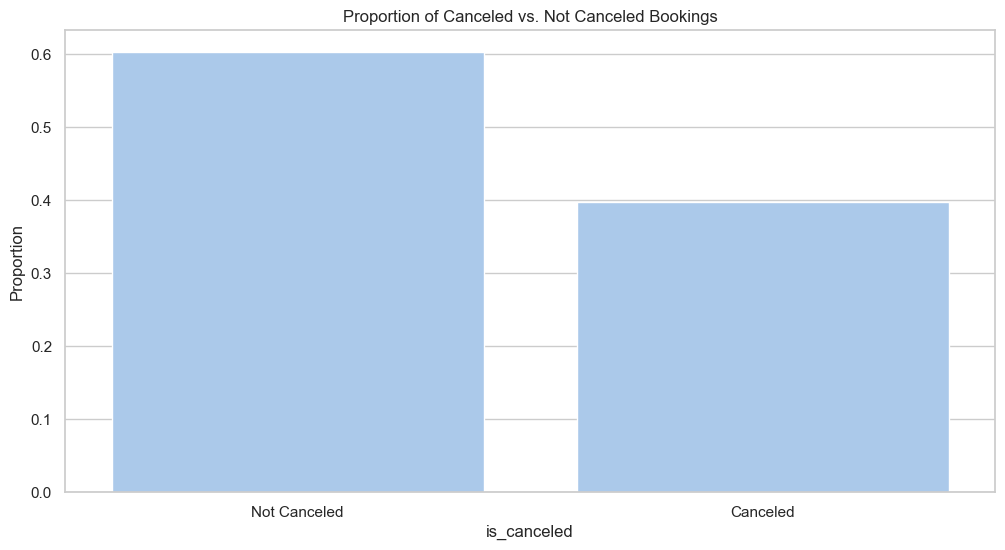

In [4]:
# 1. Cancellation rate
# This plot shows the distribution of canceled vs. non-canceled bookings
cancellation_counts = df_train['is_canceled'].value_counts(normalize=True)
sns.barplot(x=cancellation_counts.index, y=cancellation_counts.values)
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.ylabel('Proportion')
plt.title('Proportion of Canceled vs. Not Canceled Bookings')
plt.show()

# Insight: About 40% of bookings are canceled — this is significant and justifies the need for a predictive model.

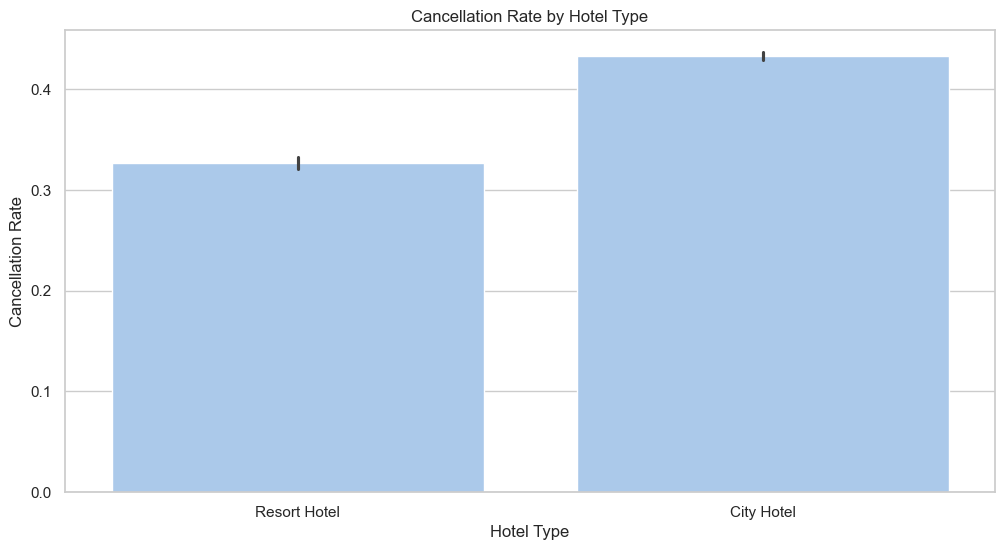

In [5]:
# 2. Cancellation rate by hotel type
# Do cancellation rates differ between resort and city hotels?
sns.barplot(data=df_train, x='hotel', y='is_canceled')
plt.title('Cancellation Rate by Hotel Type')
plt.ylabel('Cancellation Rate')
plt.xlabel('Hotel Type')
plt.show()

# Insight: Resort hotels have a higher cancellation rate than city hotels. Possibly due to seasonal or leisure-based bookings.

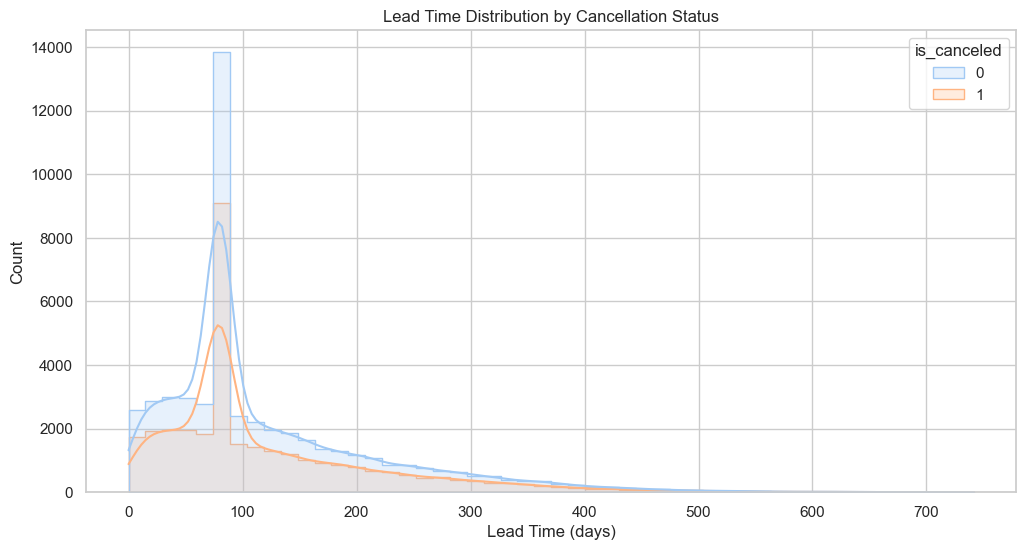

In [6]:
# 3. Lead time vs. cancellation
# Longer lead times might be more likely to cancel
sns.histplot(data=df_train, x='lead_time', hue='is_canceled', bins=50, kde=True, element="step")
plt.title('Lead Time Distribution by Cancellation Status')
plt.xlabel('Lead Time (days)')
plt.ylabel('Count')
plt.show()

# Insight: Bookings with longer lead times are more often canceled. Possibly customers book early and then change plans.

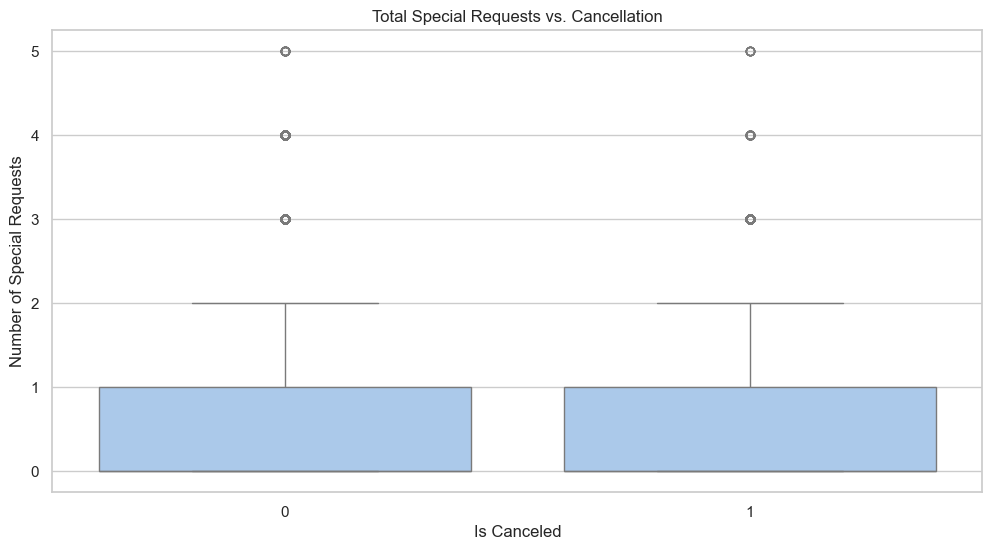

In [7]:
# 4. Special requests vs. cancellation
# Customers with more special requests might be more committed
sns.boxplot(data=df_train, x='is_canceled', y='total_of_special_requests')
plt.title('Total Special Requests vs. Cancellation')
plt.xlabel('Is Canceled')
plt.ylabel('Number of Special Requests')
plt.show()

# Insight: Non-canceled bookings typically have more special requests — suggesting stronger commitment.


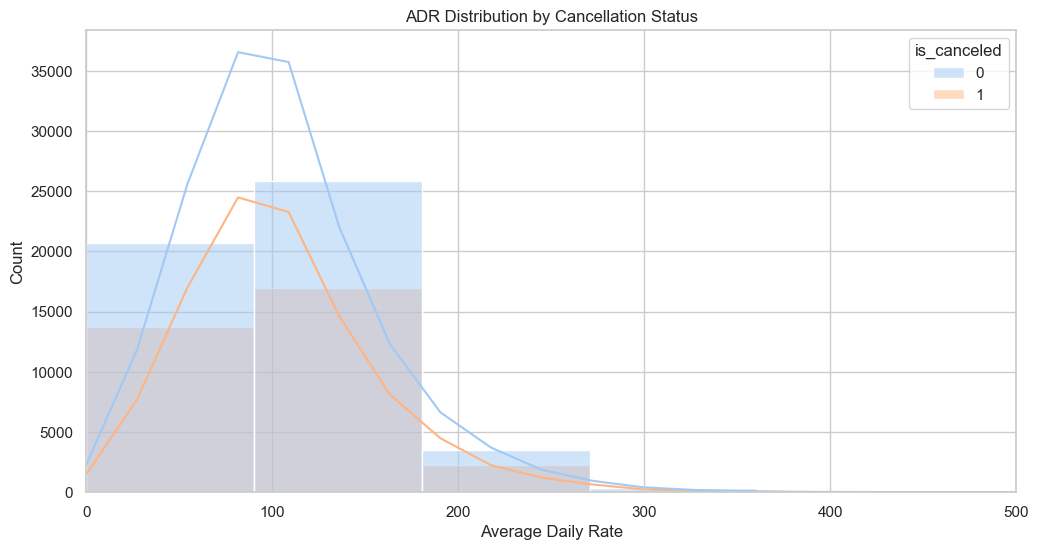

In [8]:
# 5. ADR (Average Daily Rate) distribution
# Are more expensive bookings more likely to be canceled?
sns.histplot(data=df_train, x='adr', hue='is_canceled', bins=60, kde=True)
plt.title('ADR Distribution by Cancellation Status')
plt.xlabel('Average Daily Rate')
plt.ylabel('Count')
plt.xlim(0, 500)  # limit to exclude outliers
plt.show()

# Insight: Most bookings fall under ADR < 200. Slightly more cancellations are seen in the lower ADR range.

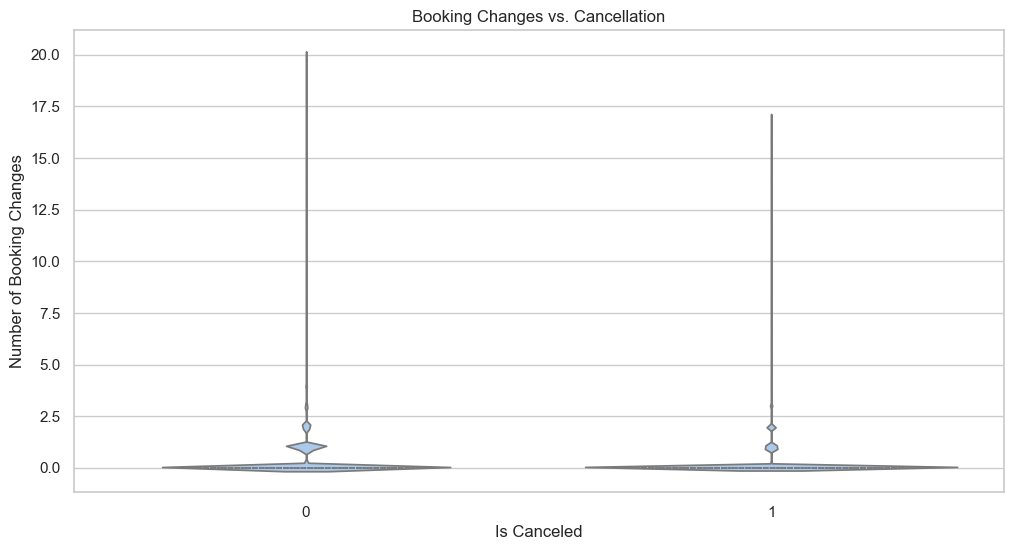

In [9]:
# 6. Booking changes and cancellations
# Do customers who change their booking cancel more?
sns.violinplot(data=df_train, x='is_canceled', y='booking_changes', inner='quart')
plt.title('Booking Changes vs. Cancellation')
plt.xlabel('Is Canceled')
plt.ylabel('Number of Booking Changes')
plt.show()

# Insight: Canceled bookings tend to have more changes — a useful predictive feature.


/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_1990/596655229.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_cancellation = df_train.groupby('arrival_date_month')['is_canceled'].mean().reset_index()


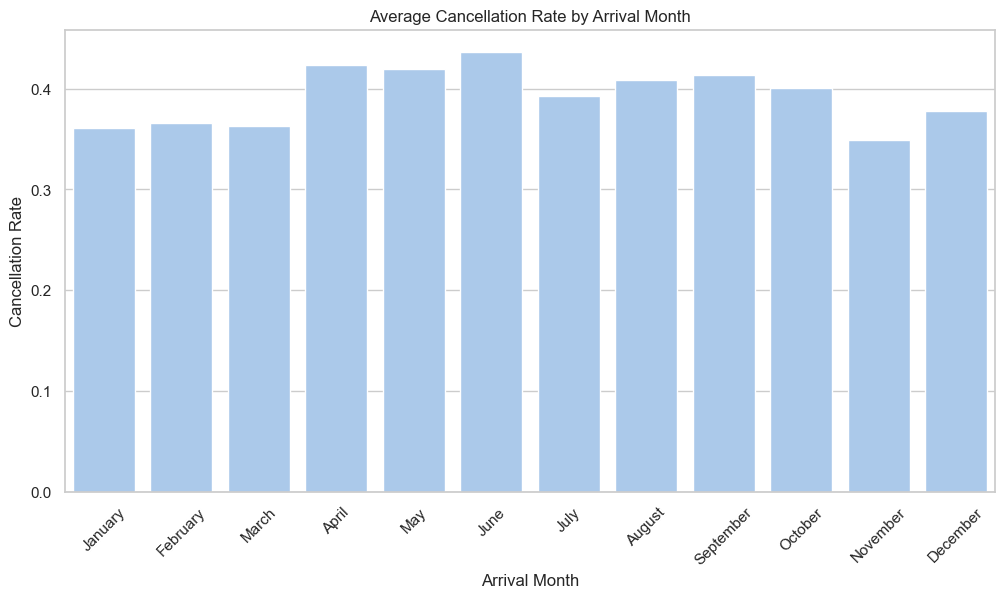

In [10]:
# 7. Monthly cancellation trends
# Are some months more prone to cancellations?
df_train['arrival_date_month'] = pd.Categorical(df_train['arrival_date_month'],
    categories=['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December'],
    ordered=True)

monthly_cancellation = df_train.groupby('arrival_date_month')['is_canceled'].mean().reset_index()
sns.barplot(data=monthly_cancellation, x='arrival_date_month', y='is_canceled')
plt.title('Average Cancellation Rate by Arrival Month')
plt.ylabel('Cancellation Rate')
plt.xlabel('Arrival Month')
plt.xticks(rotation=45)
plt.show()

# Insight: Peaks in cancellations during summer months may indicate holiday plans change more frequently.